Внимание! Данный ноутбук является демонстрационной версией исследовательского пайплайна.

Перед началом работы убедитесь, что у вас на диске существует папка, указанная в переменной BASE_DIR, либо замените ссылку на ведущую в ту папку, в которую хотите сохранять данные.

Папка DATA_DIR будет содержать промежуточные файлы данных, необходимые для организации возможности запуска блоков независимо друг от друга.

Папка MODEL_DIR предназначена для хранения обученных моделей и сопутствующих файлов.

**Важно.** Выполняйте блоки по очереди, не запускайте весь блокнот целиком. Каждый блок сохраняет промежуточные результаты, которые нужны следующим блокам. Последовательный запуск позволяет контролировать выполнение и избежать повторных вычислений в случае ошибки.

Настройка среды

In [2]:
import os

# Пути
BASE_DIR = "/content/drive/MyDrive/Научная работа"
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Установка библиотек
!python -m spacy download ru_core_news_sm
!pip install spacy bertopic
!pip install catboost

Внимание! Для обработки ваших файлов замените текущие ссылки на JSON-файлы с сообщениями Telegram в списке на свои.

Если ваши сообщения представлены в табличном формате CSV, пропустите этот блок и переходите к следующему.

1. Обработка JSON-файлов с сообщениями Telegram

In [ ]:
import pandas as pd
import json
import os
from datetime import datetime

# Список JSON-файлов для обработки
json_files = [
    "/content/drive/MyDrive/Научная работа/result1.json",  # АСИ
    "/content/drive/MyDrive/Научная работа/result2.json",  # Настоящее будущее (НТИ)
    "/content/drive/MyDrive/Научная работа/result3.json"   # Сильные идеи
]

all_messages = []

for file_path in json_files:
    if not os.path.exists(file_path):
        print(f"Файл не найден: {file_path}")
        continue

    print(f"Обработка: {os.path.basename(file_path)}")

    # Чтение JSON
    df = pd.read_json(file_path)

    # Нормализация вложенной структуры сообщений
    messages = pd.json_normalize(df["messages"])

    # Оставляем только сообщения
    if "type" in messages.columns:
        messages = messages[messages["type"] == "message"]

    # Извлечение текста
    def extract_text_simple(text_field):
        """Извлекает текст из поля 'text' сообщения Telegram."""
        if isinstance(text_field, str):
            return text_field
        elif isinstance(text_field, list):
            parts = []
            for item in text_field:
                if isinstance(item, str):
                    parts.append(item)
                elif isinstance(item, dict) and "text" in item:
                    parts.append(str(item["text"]))
            return " ".join(parts)
        elif isinstance(text_field, dict) and "text" in text_field:
            return str(text_field["text"])
        else:
            return ""

    messages["text"] = messages["text"].apply(extract_text_simple)

    # Оставляем только нужные колонки
    messages = messages[["date", "text"]].copy()
    messages.columns = ["date", "message_text"]

    # Удаляем пустые сообщения
    messages = messages[messages["message_text"].str.strip() != ""]

    # Конвертируем дату
    messages["date"] = pd.to_datetime(messages["date"])

    # Добавляем имя файла источника для информации
    messages["source"] = os.path.basename(file_path).replace(".json", "")

    all_messages.append(messages)
    print(f"Извлечено сообщений: {len(messages)}")

# Объединяем все источники в один датафрейм
df_raw = pd.concat(all_messages, ignore_index=True)
df_raw = df_raw.sort_values("date").reset_index(drop=True)

# Сохраняем промежуточный результат
output_path = os.path.join(DATA_DIR, "raw_messages.csv")
df_raw.to_csv(output_path, index=False, encoding='utf-8')

print(f"Всего сообщений: {len(df_raw)}")
print(f"Период: {df_raw['date'].min()} – {df_raw['date'].max()}")
print(f"Источники: {df_raw['source'].unique()}")
print(f"Промежуточный файл сохранен: {output_path}")

print(f"\nПервые 5 сообщений:")
df_raw[["date", "source", "message_text"]].head()

Обработка: result1.json
Извлечено сообщений: 854
Обработка: result2.json
Извлечено сообщений: 2335
Обработка: result3.json
Извлечено сообщений: 6200
Всего сообщений: 9389
Период: 2016-11-22 19:19:50 – 2025-12-29 18:26:35
Источники: ['result3' 'result2' 'result1']
Промежуточный файл сохранен: /content/drive/MyDrive/Научная работа/data/raw_messages.csv

Первые 5 сообщений:


,date,source,message_text
0,2016-11-22 19:19:50,result3,Поправки в налоговый кодекс позволят российски...
1,2016-11-22 20:28:04,result3,Для учителей создали отдельную школу! На крауд...
2,2016-11-22 22:02:15,result3,Основатель турнира естественных наук Сергей Са...
3,2016-11-23 23:59:01,result3,Как Стратегия научно-технологического развития...
4,2016-11-24 02:24:13,result3,Дмитрий Песков ( #АСИ ): «Фундаментальные иссл...


Внимание! Если вы пришли с уже готовым файлом CSV, убедитесь, что:
- Файл называется raw_messages.csv и находится в папке DATA_DIR.
- Файл содержит как минимум две колонки: date (в формате YYYY-MM-DD) и message_text.
- При несоответствии этим требованиям работа блока будет прервана.

Если все в порядке, пропустите Блок 1 и выполняйте этот.

2. Изучение и очистка сырых данных

Данные загружены из /content/drive/MyDrive/Научная работа/data/raw_messages.csv
Информация о датасете

Количество сообщений: 9389
Период: с 2016-11-22 19:19:50 до 2025-12-29 18:26:35
Количество дней: 3323

Источники:
result3: 6200 сообщений
result2: 2335 сообщений
result1: 854 сообщений

Пропущенные значения:
date            0
message_text    0
source          0
dtype: int64

Длина сообщений (символы):
Средняя: 833.5
Медиана: 743.0
Минимум: 1
Максимум: 4140


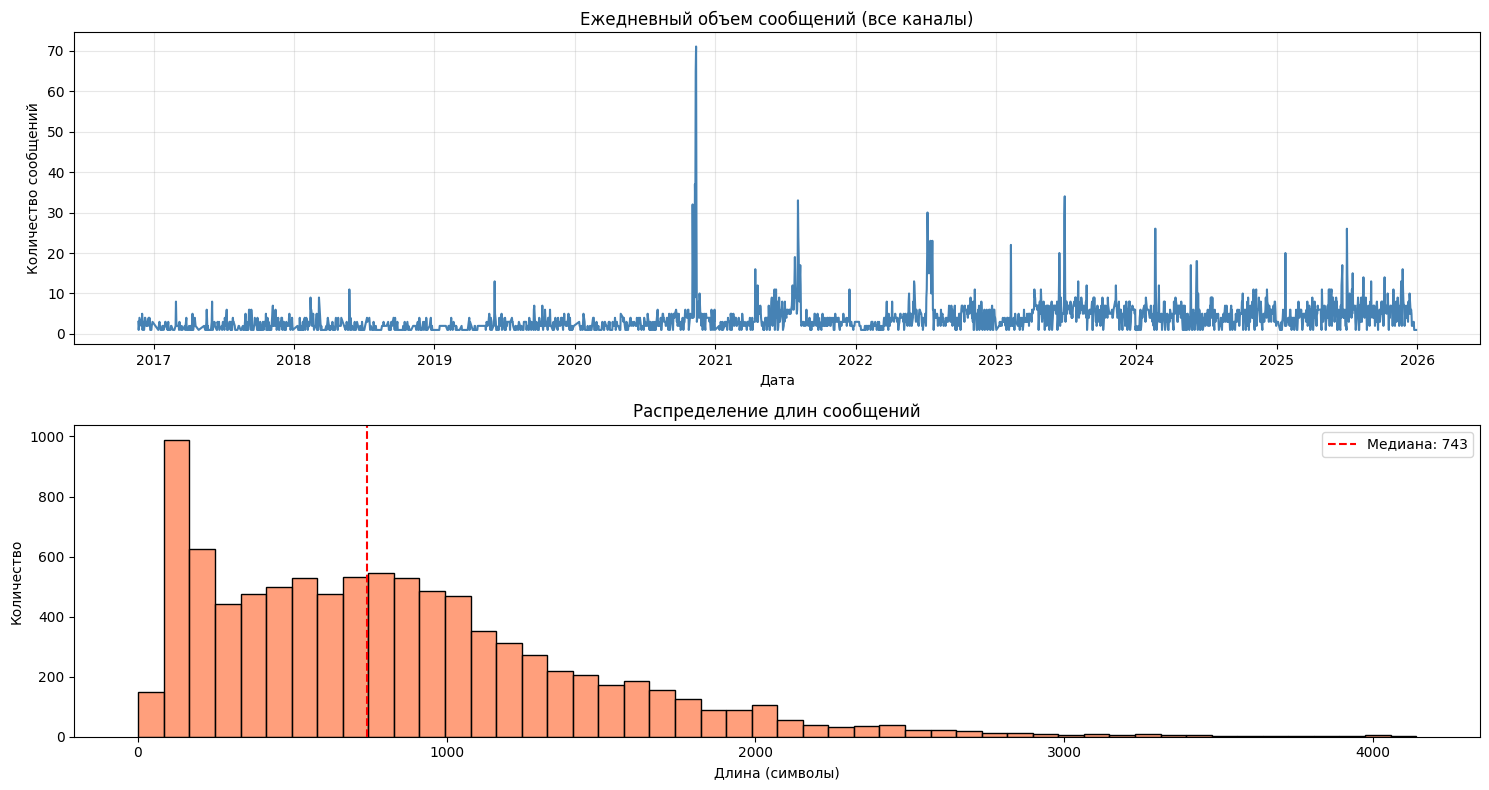

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Загружаем сохраненный ранее файл
input_path = os.path.join(DATA_DIR, "raw_messages.csv")  # Путь к табличному файлу с сообщениями

if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    if 'date' not in df.columns or 'message_text' not in df.columns:
        raise ValueError(
            f"В файле {input_path} должны быть колонки 'date' и 'message_text'.\n"
            f"Найдены колонки: {list(df.columns)}"
        )
    df['date'] = pd.to_datetime(df['date'])
    print(f"Данные загружены из {input_path}")
else:
    # Если файла нет сообщаем об ошибке
    raise FileNotFoundError(f"Файл {input_path} не найден. Сначала выполните Блок 1.")

print(f"Информация о датасете")
print(f"\nКоличество сообщений: {len(df)}")
print(f"Период: с {df['date'].min()} до {df['date'].max()}")
print(f"Количество дней: {(df['date'].max() - df['date'].min()).days}")
if 'source' in df.columns:
    print(f"\nИсточники:")
    for source in df['source'].unique():
        count = len(df[df['source'] == source])
        print(f"{source}: {count} сообщений")
print(f"\nПропущенные значения:")
print(df.isnull().sum())

# Статистика по длине сообщений
df['text_length'] = df['message_text'].apply(len)
print(f"\nДлина сообщений (символы):")
print(f"Средняя: {df['text_length'].mean():.1f}")
print(f"Медиана: {df['text_length'].median():.1f}")
print(f"Минимум: {df['text_length'].min()}")
print(f"Максимум: {df['text_length'].max()}")

# Визуализация частоты сообщений по дням
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Все сообщения
df.groupby(df['date'].dt.date).size().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Ежедневный объем сообщений (все каналы)')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество сообщений')
axes[0].grid(True, alpha=0.3)

# Распределение длин сообщений
sns.histplot(df['text_length'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Распределение длин сообщений')
axes[1].set_xlabel('Длина (символы)')
axes[1].set_ylabel('Количество')
axes[1].axvline(df['text_length'].median(), color='red', linestyle='--', label=f"Медиана: {df['text_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

3. Предобработка текста

In [ ]:
import pandas as pd
import re
import spacy
import os

# Загружаем сырые данные из Блока 2
input_path = os.path.join(DATA_DIR, "raw_messages.csv")
if os.path.exists(input_path):
    df = pd.read_csv(input_path, parse_dates=['date'])
    print(f"Загружено {len(df)} сообщений из {input_path}")
else:
    raise FileNotFoundError(f"Файл {input_path} не найден. Сначала выполните Блок 1 и 2.")

# Загрузка модели spaCy
try:
    nlp = spacy.load("ru_core_news_sm")
    print("spaCy модель загружена")
except OSError:
    print("Модель ru_core_news_sm не найдена. Устанавливаю...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "ru_core_news_sm"])
    nlp = spacy.load("ru_core_news_sm")
    print("spaCy модель установлена и загружена")

# Функция предобработки одного текста
def preprocess_text(text):
    """
    Очищает и лемматизирует текст сообщения Telegram.
    Возвращает строку из лемм, разделенных пробелами.
    """
    if not isinstance(text, str):
        return ""

    # Приведение к нижнему регистру
    text = text.lower()

    # Удаление URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Удаление упоминаний и хештегов
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Замена переносов строк на пробелы
    text = re.sub(r'\n+', ' ', text)

    # Удаление эмодзи
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"   # смайлики
        "\U0001F300-\U0001F5FF"   # символы и пиктограммы
        "\U0001F680-\U0001F6FF"   # транспорт и карты
        "\U0001F700-\U0001F77F"   # алхимические символы
        "\U0001F780-\U0001F7FF"   # геометрические фигуры
        "\U0001F800-\U0001F8FF"   # дополнительные стрелки
        "\U0001F900-\U0001F9FF"   # дополнительные символы
        "\U0001FA00-\U0001FA6F"   # шахматы
        "\U0001FA70-\U0001FAFF"   # расширенные символы
        "\U00002702-\U000027B0"   # дингбаты
        "\U000024C2-\U0001F251"   # окруженные идеограммы
        "\U0001F1E0-\U0001F1FF"   # флаги
        "\U0001F004"              # маджонг
        "\U0001F0CF"              # игральные карты
        "\U0001F18E"              # негативные буквы
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    # Лемматизация через spaCy
    doc = nlp(text)

    tokens = []
    for token in doc:
        if (not token.is_stop
            and not token.is_punct
            and not token.is_space
            and len(token.lemma_) > 2
            and token.lemma_.isalpha()):
            tokens.append(token.lemma_)

    return " ".join(tokens)

# Применение предобработки ко всем сообщениям
print("\nЗапуск предобработки текстов (это может занять несколько минут)...")
df['processed_text'] = df['message_text'].apply(preprocess_text)

# Фильтрация: удаление сообщений, ставших слишком короткими после обработки
MIN_PROCESSED_LENGTH = 10
before_filter = len(df)
df = df[df['processed_text'].str.len() >= MIN_PROCESSED_LENGTH].copy()
after_filter = len(df)
print(f"Предобработка завершена")
print(f"Сообщений до фильтрации: {before_filter}")
print(f"Сообщений после фильтрации (мин. длина {MIN_PROCESSED_LENGTH}): {after_filter}")
print(f"Удалено коротких/пустых: {before_filter - after_filter}")

# Добавление временных признаков
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['day'] = df['date'].dt.day
df['time_period'] = df['date'].dt.to_period('M')

# Сохранение обработанного датафрейма
output_path = os.path.join(DATA_DIR, "df_processed.csv")
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"\nОбработанные данные сохранены в: {output_path}")

print(f"\nСтатистика после предобработки\n")
print(f"Всего сообщений: {len(df)}")
print(f"Средняя длина обработанного текста (слов): {df['processed_text'].str.split().str.len().mean():.1f}")
print(f"Медианная длина: {df['processed_text'].str.split().str.len().median():.0f}")

print(f"\nПримеры обработанных сообщений:")
for i in range(min(3, len(df))):
    original = df.iloc[i]['message_text'][:100].replace('\n', ' ')
    processed = df.iloc[i]['processed_text'][:100]
    print(f"\nИсходное: {original}...")
    print(f"Обработанное: {processed}...")

Загружено 9389 сообщений из /content/drive/MyDrive/Научная работа/data/raw_messages.csv
spaCy модель загружена

Запуск предобработки текстов (это может занять несколько минут)...
Предобработка завершена
Сообщений до фильтрации: 9389
Сообщений после фильтрации (мин. длина 10): 9370
Удалено коротких/пустых: 19

Обработанные данные сохранены в: /content/drive/MyDrive/Научная работа/data/df_processed.csv

Статистика после предобработки

Всего сообщений: 9370
Средняя длина обработанного текста (слов): 69.7
Медианная длина: 61

Примеры обработанных сообщений:

Исходное: Поправки в налоговый кодекс позволят российским компаниям экономить на подготовке кадров десятки мил...
Обработанное: поправка налоговый кодекс позволить российский компания экономить подготовка кадр десяток миллион ру...

Исходное: Для учителей создали отдельную школу! На краудсорсинговой платформе «Образование будущего» запущен ц...
Обработанное: учитель создать отдельный школа краудсорсинговый платформа образование будущее

4. Тематическое моделирование BERTopic

In [ ]:
import pandas as pd
import numpy as np
import os
import json
from datetime import datetime

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import umap
import hdbscan

# Загружаем обработанные данные из Блока 3
input_path = os.path.join(DATA_DIR, "df_processed.csv")
if os.path.exists(input_path):
    df = pd.read_csv(input_path, parse_dates=['date'])
    df['time_period'] = pd.PeriodIndex(df['time_period'], freq='M')
    print(f"Загружено {len(df)} обработанных сообщений из {input_path}")
else:
    raise FileNotFoundError(f"Файл {input_path} не найден. Сначала выполните Блок 3.")

# Подготовка документов
documents = df['processed_text'].tolist()
timestamps = df['date'].tolist()

print(f"\nКоличество документов: {len(documents)}")
print(f"Пример документа: {documents[0][:150]}...")


# Определение стоп-слов

# Маркеры каналов + общая дискурсивная лексика
current_stopwords = [
    # Маркеры источников
    "аси", "агентство", "стратегический", "инициатива",
    "нти", "росконгресс",
    # Общие дискурсивные маркеры
    "форум", "идея", "сильный", "новый", "время",
    "настоящий", "будущее",
    "проект", "программа", "конкурс", "развитие",
    # Общестрановые термины
    "россия", "российский", "рф", "федерация",
    "год", "человек", "страна",
    "путин", "владимир", "президент"
]

print(f"\nВыбранный набор стоп-слов ({len(current_stopwords)} слов):")
print(current_stopwords)

# Сохраняем выбранный набор для отчета
experiment_config = {
    'stopwords_list': current_stopwords,
    'stopwords_count': len(current_stopwords),
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}


# Настройка моделей

# Векторизатор с выбранными стоп-словами
vectorizer_model = CountVectorizer(stop_words=current_stopwords)

# Модель эмбеддингов
print("\nЗагрузка модели эмбеддингов...")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("Модель эмбеддингов загружена")

# UMAP с фиксированным random_state
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)


# Обучение BERTopic

print("\nОбучение BERTopic (это может занять несколько минут)...")

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    min_topic_size=15,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=True
)

# Обучение на документах
topics, probabilities = topic_model.fit_transform(documents)

print("Обучение завершено")


# Добавление результатов в датафрейм

df['topic'] = topics
df['topic_probability'] = probabilities.max(axis=1)


# Анализ результатов

topic_info = topic_model.get_topic_info()

print(f"\nРезультаты BERTopic\n")
print(f"Всего тем (включая -1): {len(topic_info)}")
print(f"Сообщений в шуме (-1): {topic_info[topic_info['Topic'] == -1]['Count'].values[0]}")
print(f"Доля шума: {topic_info[topic_info['Topic'] == -1]['Count'].values[0] / len(df) * 100:.1f}%")

# Топ-10 тем по размеру
print(f"\nТоп-10 тем:")
for _, row in topic_info[topic_info['Topic'] != -1].head(10).iterrows():
    topic_id = row['Topic']
    count = row['Count']
    # Топ-слова темы
    top_words = [word for word, _ in topic_model.get_topic(topic_id)[:6]]
    words_str = ", ".join(top_words)
    print(f"  Тема {topic_id:3d} | {count:5d} сообщ. | {words_str}")


# Межтематическая карта
fig_topics = topic_model.visualize_topics()
fig_topics.write_html(os.path.join(DATA_DIR, "topic_map.html"))
print(f"Карта тем сохранена в topic_map.html")

# Топ-слова по темам
fig_barchart = topic_model.visualize_barchart(top_n_topics=15)
fig_barchart.write_html(os.path.join(DATA_DIR, "topic_barchart.html"))
print(f"Топ слов сохранен в topic_barchart.html")

# Сохраняем датафрейм с темами
df_output_path = os.path.join(DATA_DIR, "df_with_topics.csv")
df.to_csv(df_output_path, index=False, encoding='utf-8')

# Сохраняем модель BERTopic
model_path = os.path.join(MODEL_DIR, "bertopic_model")
topic_model.save(model_path, serialization="pytorch", save_ctfidf=True)
print(f"Модель BERTopic сохранена в: {model_path}")

# Сохраняем информацию о темах
topic_info_dict = {}
for topic_id in topic_info['Topic'].tolist():
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:8]]
        topic_info_dict[str(topic_id)] = {
            'topic_id': int(topic_id),
            'count': int(topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]),
            'keywords': words
        }

topic_meta_path = os.path.join(DATA_DIR, "topic_metadata.json")
with open(topic_meta_path, "w", encoding="utf-8") as f:
    json.dump(topic_info_dict, f, ensure_ascii=False, indent=2)

# Сохраняем конфигурацию эксперимента
config_path = os.path.join(DATA_DIR, "experiment_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)

print(f"\nВсе результаты сохранены:")
print(f"{df_output_path} – датафрейм с темами")
print(f"{model_path}/ – модель BERTopic")
print(f"{topic_meta_path} – метаданные тем (ключевые слова)")
print(f"{config_path} – конфигурация эксперимента")

Загружено 9370 обработанных сообщений из /content/drive/MyDrive/Научная работа/data/df_processed.csv

Количество документов: 9370
Пример документа: поправка налоговый кодекс позволить российский компания экономить подготовка кадр десяток миллион рубль...

Выбранный набор стоп-слов (27 слов):
['аси', 'агентство', 'стратегический', 'инициатива', 'нти', 'росконгресс', 'форум', 'идея', 'сильный', 'новый', 'время', 'настоящий', 'будущее', 'проект', 'программа', 'конкурс', 'развитие', 'россия', 'российский', 'рф', 'федерация', 'год', 'человек', 'страна', 'путин', 'владимир', 'президент']

Загрузка модели эмбеддингов...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-05-26 15:46:15,617 - BERTopic - Embedding - Transforming documents to embeddings.


Модель эмбеддингов загружена

Обучение BERTopic (это может занять несколько минут)...


Batches:   0%|          | 0/293 [00:00<?, ?it/s]

2026-05-26 15:59:29,513 - BERTopic - Embedding - Completed ✓
2026-05-26 15:59:29,516 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-26 16:00:24,128 - BERTopic - Dimensionality - Completed ✓
2026-05-26 16:00:24,130 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-26 16:00:27,157 - BERTopic - Cluster - Completed ✓
2026-05-26 16:00:27,158 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-26 16:00:27,992 - BERTopic - Representation - Completed ✓
2026-05-26 16:00:27,994 - BERTopic - Topic reduction - Reducing number of topics
2026-05-26 16:00:28,019 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-26 16:00:28,869 - BERTopic - Representation - Completed ✓
2026-05-26 16:00:28,873 - BERTopic - Topic reduction - Reduced number of topics from 78 to 68


Обучение завершено

Результаты BERTopic

Всего тем (включая -1): 68
Сообщений в шуме (-1): 3265
Доля шума: 34.8%

Топ-10 тем:
  Тема   0 |   677 сообщ. | дрон, беспилотный, бас, беспилотник, система, авиационный
  Тема   1 |   654 сообщ. | стартап, бизнес, предприниматель, команда, акселератор, заявка
  Тема   2 |   426 сообщ. | архипелаг, интенсив, команда, участник, июль, университет
  Тема   3 |   262 сообщ. | креативный, индустрия, экономика, творческий, партнёр, продюсер
  Тема   4 |   254 сообщ. | автор, глава, регион, директор, генеральный, заседание
  Тема   5 |   248 сообщ. | туризм, туристический, маршрут, тропа, турист, промышленный
  Тема   6 |   236 сообщ. | бренд, победитель, одежда, номинация, продукция, рост
  Тема   7 |   218 сообщ. | университет, государственный, кино, фестиваль, цска, область
  Тема   8 |   207 сообщ. | социальный, качество, регион, жизнь, региональный, услуга
  Тема   9 |   204 сообщ. | экологический, отход, климатический, экология, климат, адаптаци

In [ ]:
df.head()

,date,message_text,source,processed_text,year,month,week,day,time_period,topic,topic_probability
0,2016-11-22 19:19:50,Поправки в налоговый кодекс позволят российски...,result3,поправка налоговый кодекс позволить российский...,2016,11,47,22,2016-11,4,0.142789
1,2016-11-22 20:28:04,Для учителей создали отдельную школу! На крауд...,result3,учитель создать отдельный школа краудсорсингов...,2016,11,47,22,2016-11,1,1.000000
2,2016-11-22 22:02:15,Основатель турнира естественных наук Сергей Са...,result3,основатель турнир естественный наука сергей са...,2016,11,47,22,2016-11,-1,0.047586
3,2016-11-23 23:59:01,Как Стратегия научно-технологического развития...,result3,стратегия научный технологический развитие обе...,2016,11,47,23,2016-11,1,0.081989
4,2016-11-24 02:24:13,Дмитрий Песков ( #АСИ ): «Фундаментальные иссл...,result3,дмитрий песков фундаментальный исследование да...,2016,11,47,24,2016-11,-1,0.006263


5. Визуализация и анализ тем

Загружено 9370 сообщений с темами
Распределение сообщений по годам:
date
2016      65
2017     449
2018     385
2019     470
2020     943
2021    1163
2022    1316
2023    1512
2024    1433
2025    1634
dtype: int64

Уникальных недель с сообщениями: 464
Первая неделя: 2016-11-21/2016-11-27
Последняя неделя: 2025-12-29/2026-01-04
Всего недель в диапазоне: 476
Из них с сообщениями: 464 (97.5%)


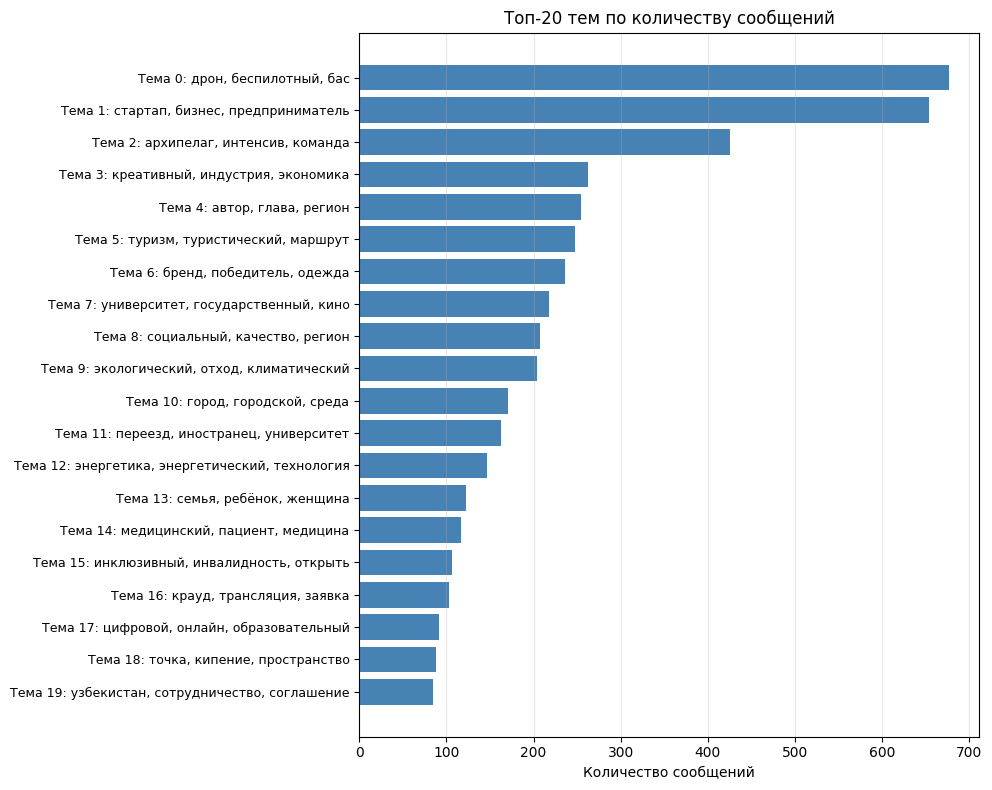

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Загружаем данные с темами
df_path = os.path.join(DATA_DIR, "df_with_topics.csv")
df = pd.read_csv(df_path, parse_dates=['date'])

print(f"Загружено {len(df)} сообщений с темами")

# Проверка: распределение сообщений по годам
print("Распределение сообщений по годам:")
year_counts = df.groupby(df['date'].dt.year).size()
print(year_counts)

# Проверка: сколько уникальных недель в данных
all_weeks = df['date'].dt.to_period('W').unique()
print(f"\nУникальных недель с сообщениями: {len(all_weeks)}")
print(f"Первая неделя: {all_weeks.min()}")
print(f"Последняя неделя: {all_weeks.max()}")

# Проверка: сколько недель в полном диапазоне
from datetime import datetime
full_range_weeks = len(pd.period_range(start=all_weeks.min(), end=all_weeks.max(), freq='W'))
print(f"Всего недель в диапазоне: {full_range_weeks}")
print(f"Из них с сообщениями: {len(all_weeks)} ({len(all_weeks)/full_range_weeks*100:.1f}%)")

# Загружаем ключевые слова тем из файла
metadata_path = os.path.join(DATA_DIR, "topic_metadata.json")
if os.path.exists(metadata_path):
    with open(metadata_path, "r", encoding="utf-8") as f:
        topic_metadata = json.load(f)

    topic_names = {}
    for topic_id_str, info in topic_metadata.items():
        topic_id = int(topic_id_str)
        if topic_id == -1:
            topic_names[topic_id] = "Шум (-1)"
        else:
            # Берем первые три слова из сохраненных ключевых слов
            words = info.get('keywords', [])[:3]
            topic_names[topic_id] = f"Тема {topic_id}: {', '.join(words)}" if words else f"Тема {topic_id}"
else:
    # Заглушки названий для тем
    print(f"Файл {metadata_path} не найден. Будут использованы заглушки.")
    topic_names = {topic_id: f"Тема_{topic_id}" for topic_id in df['topic'].unique()}
    topic_names[-1] = "Шум (-1)"

df['topic_name'] = df['topic'].map(topic_names)

# Показываем распределение топ-20 тем, исключая шум
topic_counts = df[df['topic'] != -1]['topic_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(topic_counts)), topic_counts.values, color='steelblue')
ax.set_yticks(range(len(topic_counts)))
ax.set_yticklabels(topic_counts.index, fontsize=9)
ax.set_xlabel('Количество сообщений')
ax.set_title('Топ-20 тем по количеству сообщений')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Внимание! Код содержит ручную фильтрацию тем 2 и 4, специфичную для имеющегося корпуса данных.

При переносе на другие данные, номера исключаемых тем эксперту необходимо определить самостоятельно.

6. Формирование временных рядов для прогнозирования

In [17]:
import pandas as pd
import numpy as np
import json
import os

# Список номеров тем для фильтрации
EXCLUDED_TOPIC_IDS = [2, 4]

# Загружаем данные с темами
df_path = os.path.join(DATA_DIR, "df_with_topics.csv")
df = pd.read_csv(df_path, parse_dates=['date'])

# Получаем названия тем
metadata_path = os.path.join(DATA_DIR, "topic_metadata.json")
if os.path.exists(metadata_path):
    with open(metadata_path, "r", encoding="utf-8") as f:
        topic_metadata = json.load(f)

    topic_names = {}
    for topic_id_str, info in topic_metadata.items():
        topic_id = int(topic_id_str)
        if topic_id == -1:
            topic_names[topic_id] = "Шум"
        else:
            # Берем первые три слова из сохраненных ключевых слов
            words = info.get('keywords', [])[:3]
            topic_names[topic_id] = f"{topic_id}_{'_'.join(words)}" if words else f"Тема_{topic_id}"

    print(f"Загружены названия для {len(topic_names)} тем из topic_metadata.json\n")
else:
    # Заглушки названий для тем
    print(f"Файл {metadata_path} не найден. Будут использованы заглушки.")
    topic_names = {topic_id: f"Тема_{topic_id}" for topic_id in df['topic'].unique()}
    topic_names[-1] = "Шум"

df['topic_name'] = df['topic'].map(topic_names)

# Создаем недельную агрегацию
df['week_period'] = df['date'].dt.to_period('W')
topic_weekly = df.groupby(['week_period', 'topic_name']).size().unstack(fill_value=0)

# Создаем полный индекс недель
full_weeks = pd.period_range(
    start=df['week_period'].min(),
    end=df['week_period'].max(),
    freq='W'
)
topic_weekly = topic_weekly.reindex(full_weeks, fill_value=0)

print(f"Размер полной таблицы: {topic_weekly.shape}")
print(f"Недель: {topic_weekly.shape[0]}")
print(f"Тем: {topic_weekly.shape[1]}")
print(f"Период: {topic_weekly.index.min()} – {topic_weekly.index.max()}")

cols_to_drop = []

# Убираем шум
if 'Шум' in topic_weekly.columns:
    topic_weekly = topic_weekly.drop(columns=['Шум'])

# Ищем и удаляем темы с id из EXCLUDED_TOPIC_IDS
for col in topic_weekly.columns:
    for topic_id in EXCLUDED_TOPIC_IDS:
        if col.startswith(f'{topic_id}_'):
            cols_to_drop.append(col)
            break

topic_weekly = topic_weekly.drop(columns=cols_to_drop, errors='ignore')
print(f"Удалены темы: {cols_to_drop}")

# Выбираем топ-5 тем по общему объему
topic_totals = topic_weekly.sum().sort_values(ascending=False)
top_5_topics = topic_totals.head(5).index.tolist()

print(f"\nТоп-5 тем для прогнозирования:")
for i, col in enumerate(top_5_topics):
    print(f"{i+1}. {col} – {int(topic_totals[col])} сообщ.")

# Создаем датафрейм только с топ-5 темами
trends_top5 = topic_weekly[top_5_topics].copy()
trends_top5.index = trends_top5.index.to_timestamp()

print(f"\nИтоговая таблица для прогнозирования:")
print(f"Размер: {trends_top5.shape}")
print(f"Недель: {len(trends_top5)}")
print(f"Тем: {trends_top5.columns.tolist()}")

# Сохраняем для следующих блоков
output_path = os.path.join(DATA_DIR, "topic_trends_top5.csv")
trends_top5.to_csv(output_path, encoding='utf-8')
print(f"\nТаблица трендов сохранена: {output_path}")

print(f"\nПервые 5 строк:")
print(trends_top5.head())
print(f"\nПоследние 5 строк:")
print(trends_top5.tail())

Загружены названия для 67 тем из topic_metadata.json

Размер полной таблицы: (476, 67)
Недель: 476
Тем: 67
Период: 2016-11-21/2016-11-27 – 2025-12-29/2026-01-04
Удалены темы: ['2_архипелаг_интенсив_команда', '4_путин_владимир_президент']

Топ-5 тем для прогнозирования:
1. 0_дрон_беспилотный_бас – 677 сообщ.
2. 1_стартап_бизнес_предприниматель – 654 сообщ.
3. 3_креативный_индустрия_экономика – 262 сообщ.
4. 5_туризм_туристический_маршрут – 248 сообщ.
5. 6_бренд_победитель_одежда – 236 сообщ.

Итоговая таблица для прогнозирования:
Размер: (476, 5)
Недель: 476
Тем: ['0_дрон_беспилотный_бас', '1_стартап_бизнес_предприниматель', '3_креативный_индустрия_экономика', '5_туризм_туристический_маршрут', '6_бренд_победитель_одежда']

Таблица трендов сохранена: /content/drive/MyDrive/Научная работа/data/topic_trends_top5.csv

Первые 5 строк:
topic_name  0_дрон_беспилотный_бас  1_стартап_бизнес_предприниматель  \
2016-11-21                       0                                 3   
2016-11-28     

7. Анализ временных рядов

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(os.path.join(DATA_DIR, "topic_trends_top5.csv"), index_col=0, parse_dates=True)
df = df.sort_index()
topics = df.columns.tolist()

df.describe()

,0_дрон_беспилотный_бас,1_стартап_бизнес_предприниматель,3_креативный_индустрия_экономика,5_туризм_туристический_маршрут,6_бренд_победитель_одежда
count,476.000000,476.000000,476.000000,476.000000,476.000000
mean,1.422269,1.373950,0.550420,0.521008,0.495798
std,2.379794,1.735958,1.315327,0.923141,1.316288
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,0.000000
max,21.000000,22.000000,16.000000,6.000000,11.000000


Визуализация временных рядов по всем темам

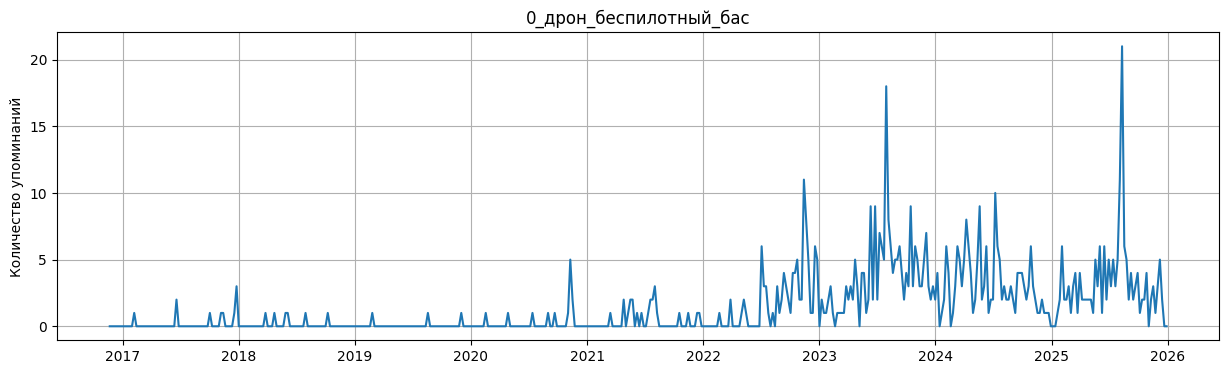

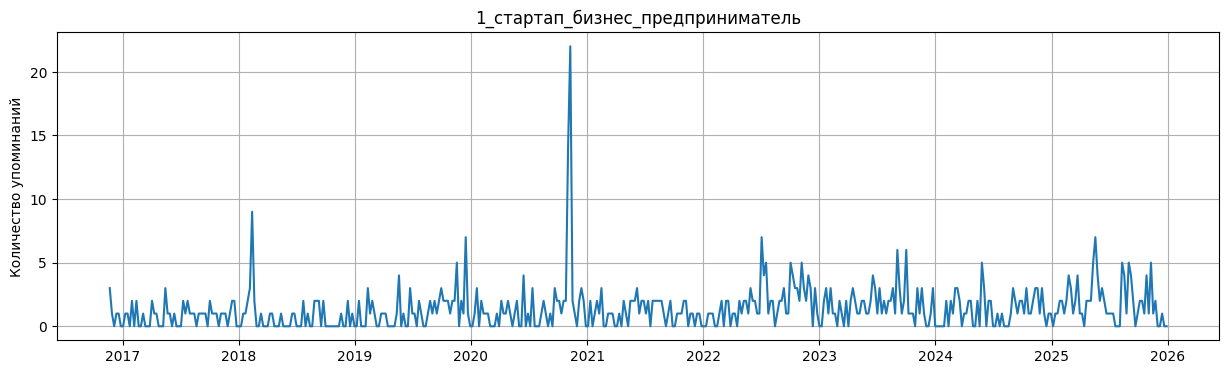

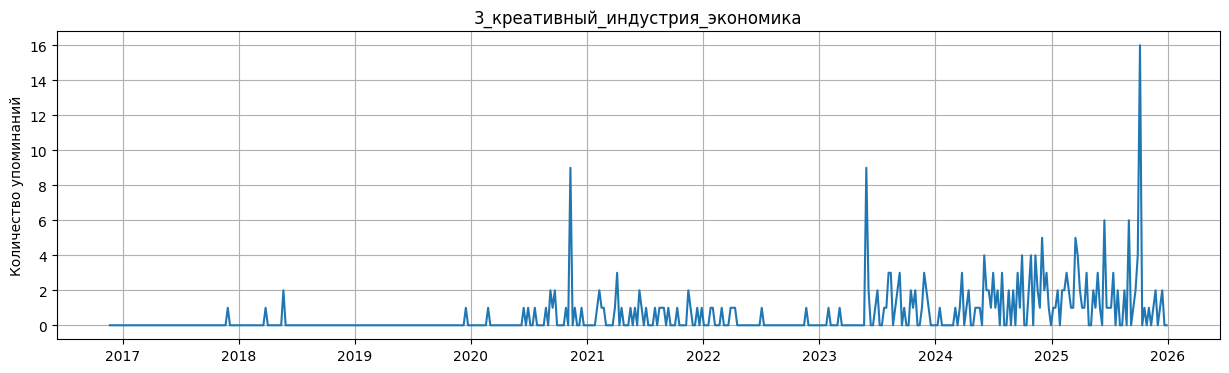

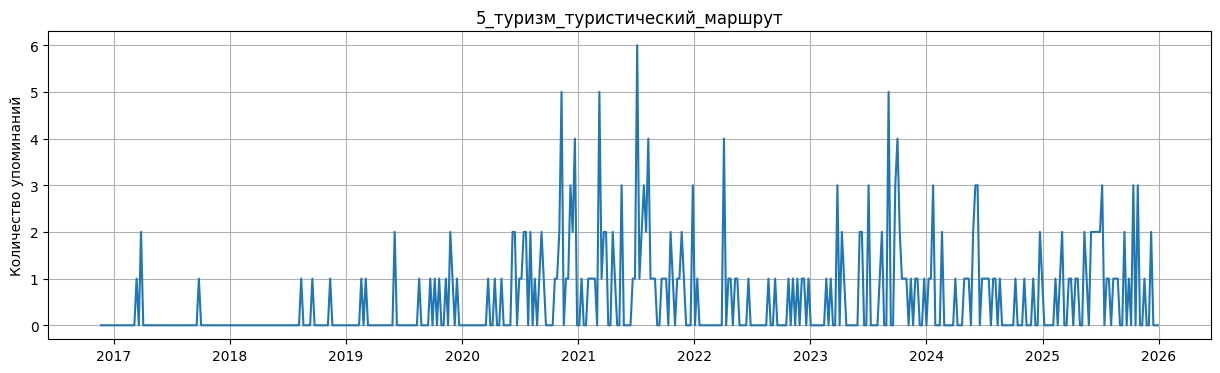

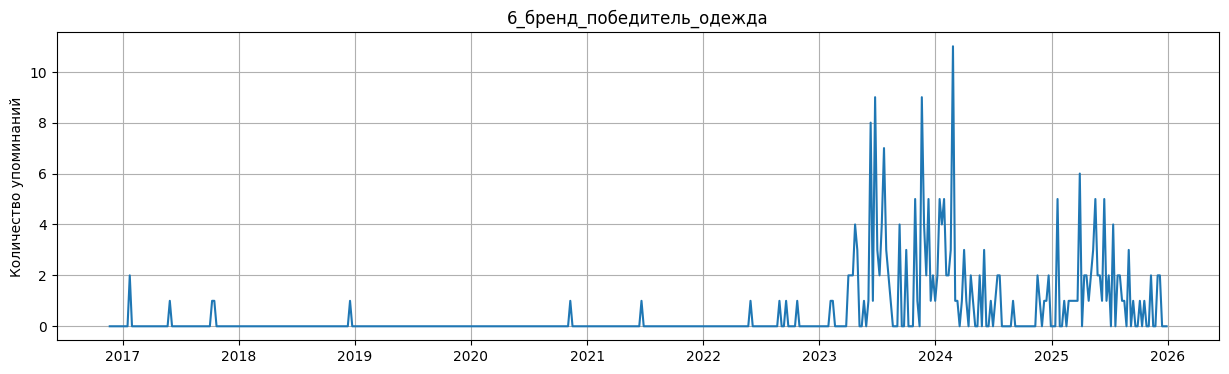

In [ ]:
for topic in df.columns:
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(df[topic])
    ax.set_title(topic)
    ax.grid(True)
    ax.set_ylabel('Количество упоминаний')

plt.show()

Декомпозиция временных рядов

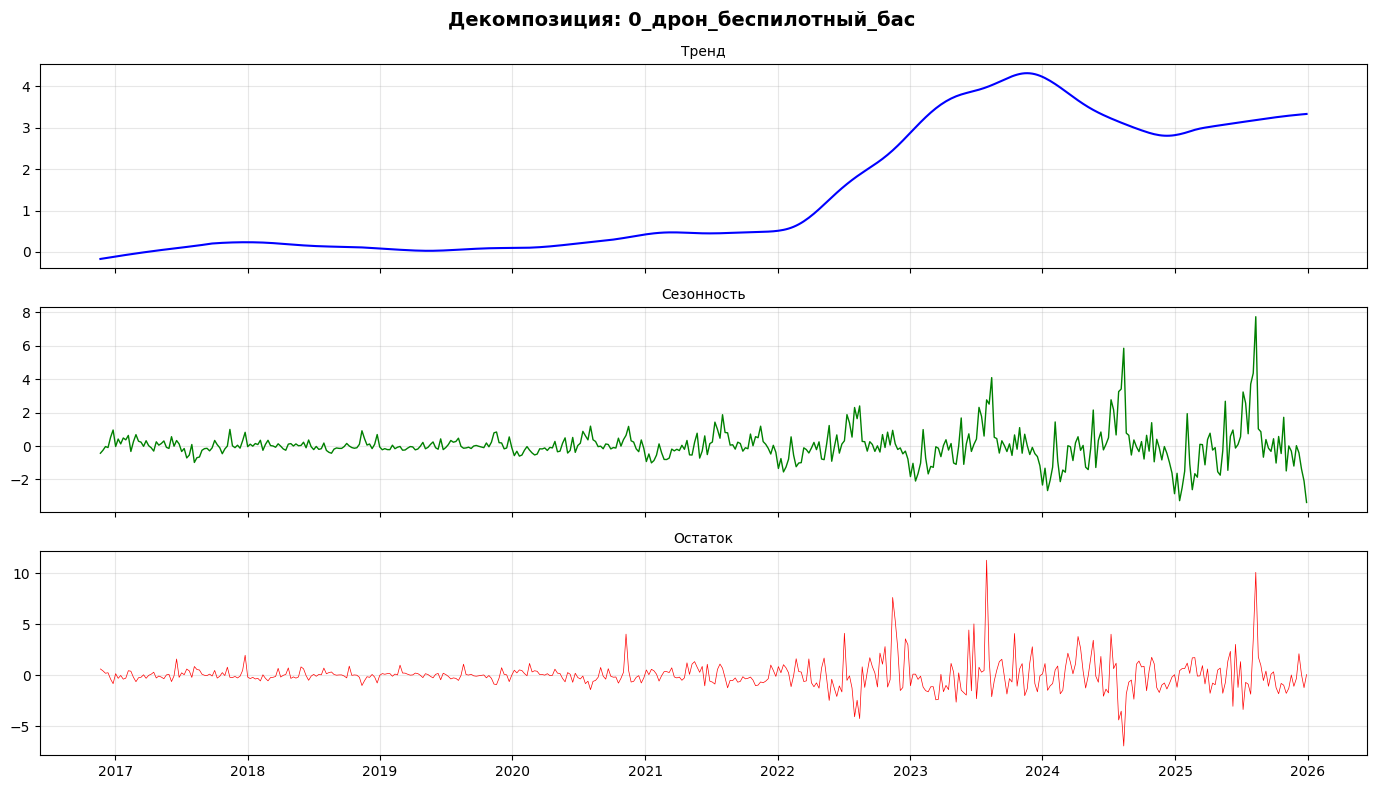

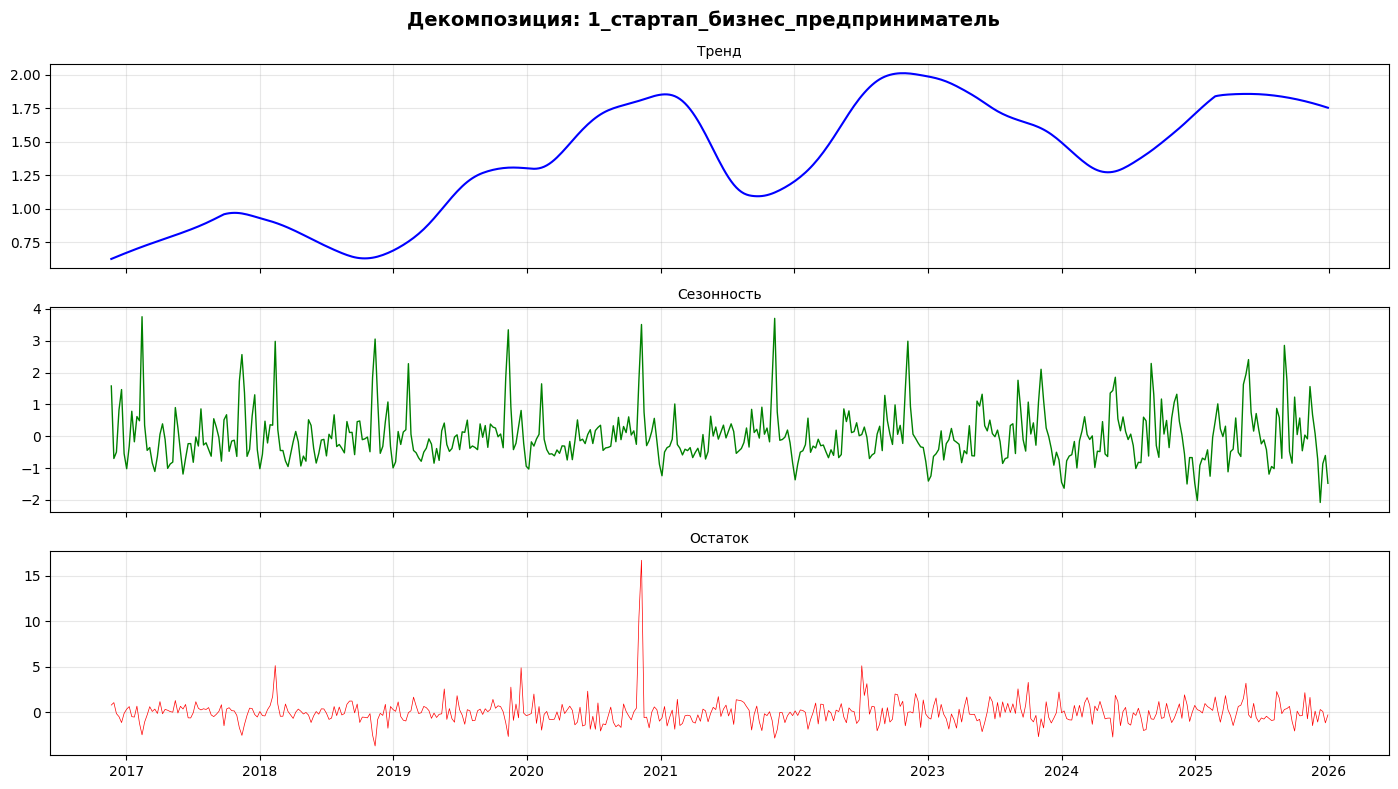

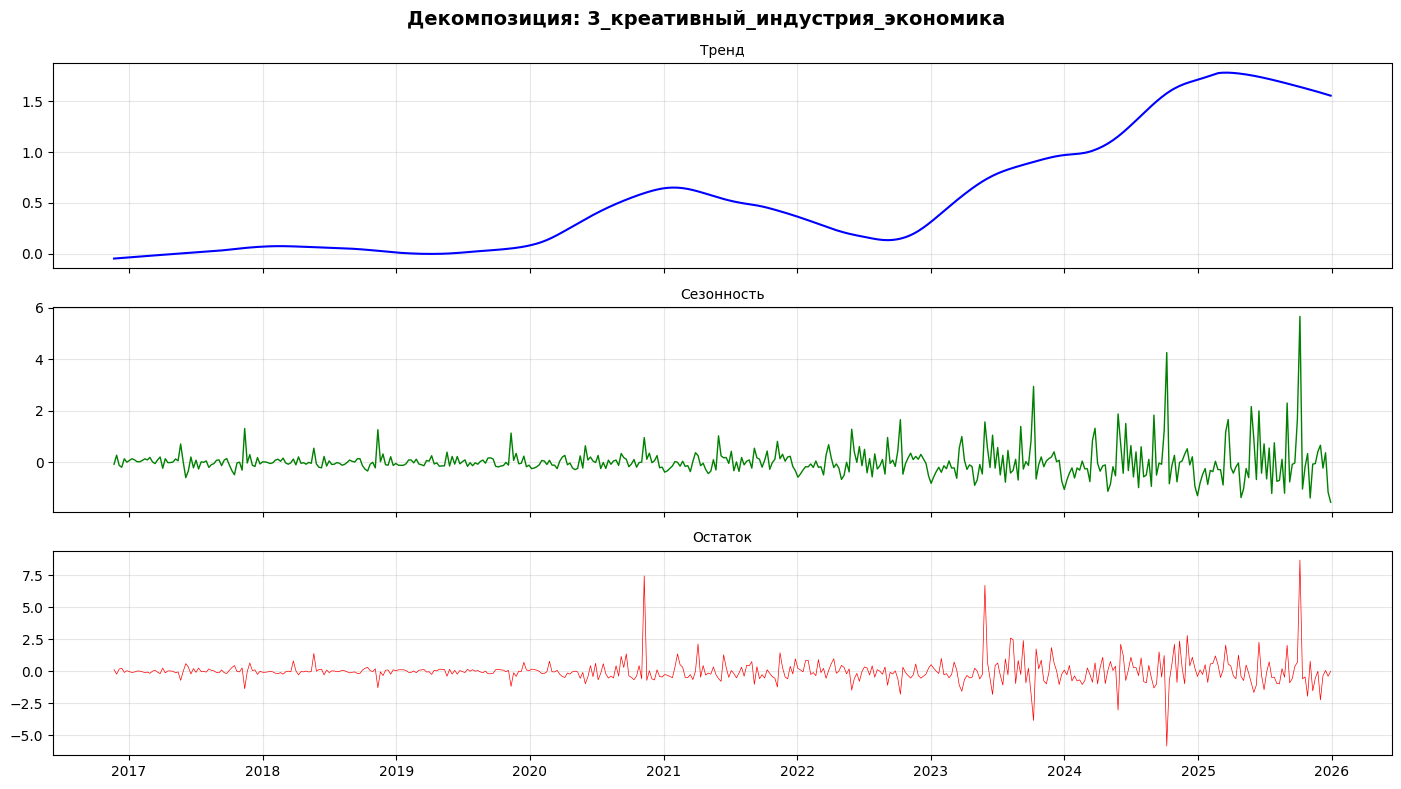

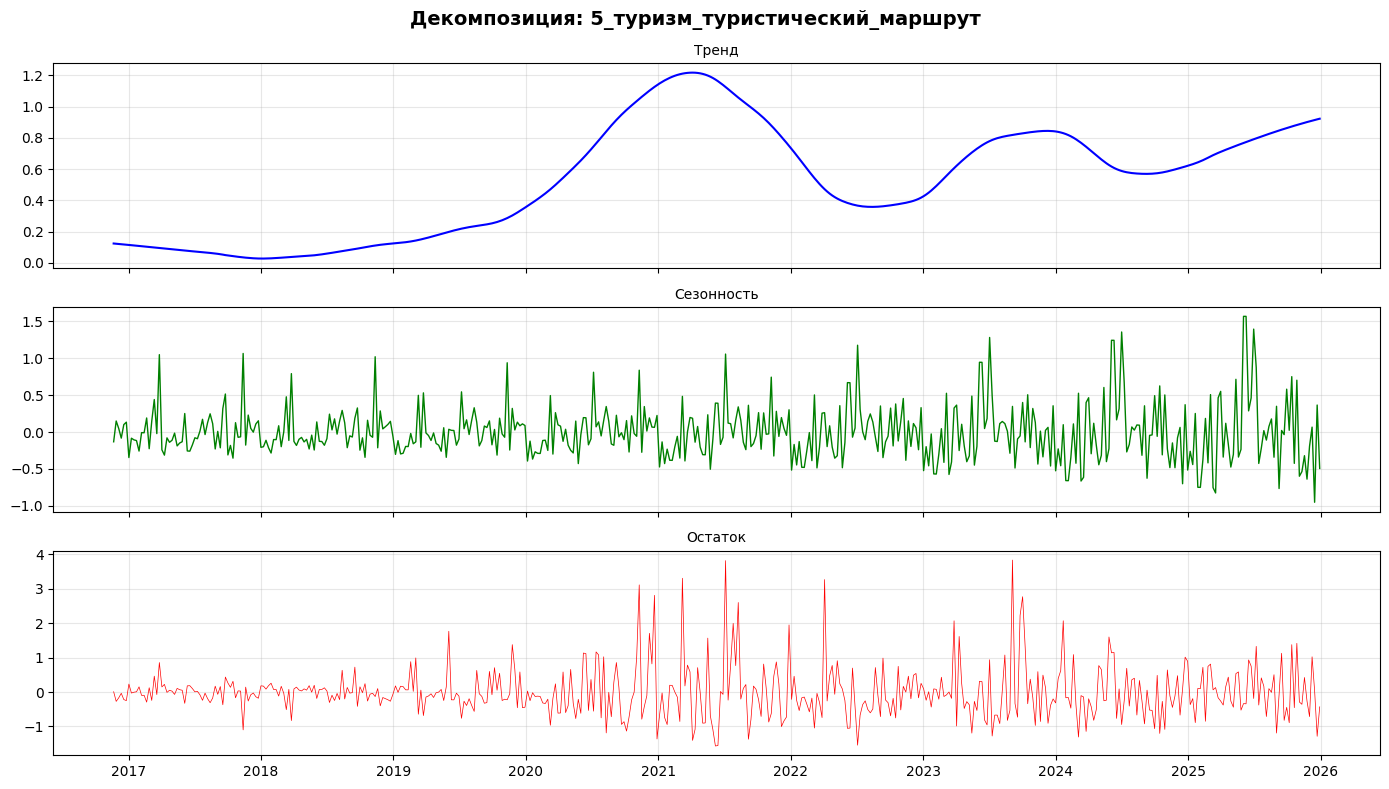

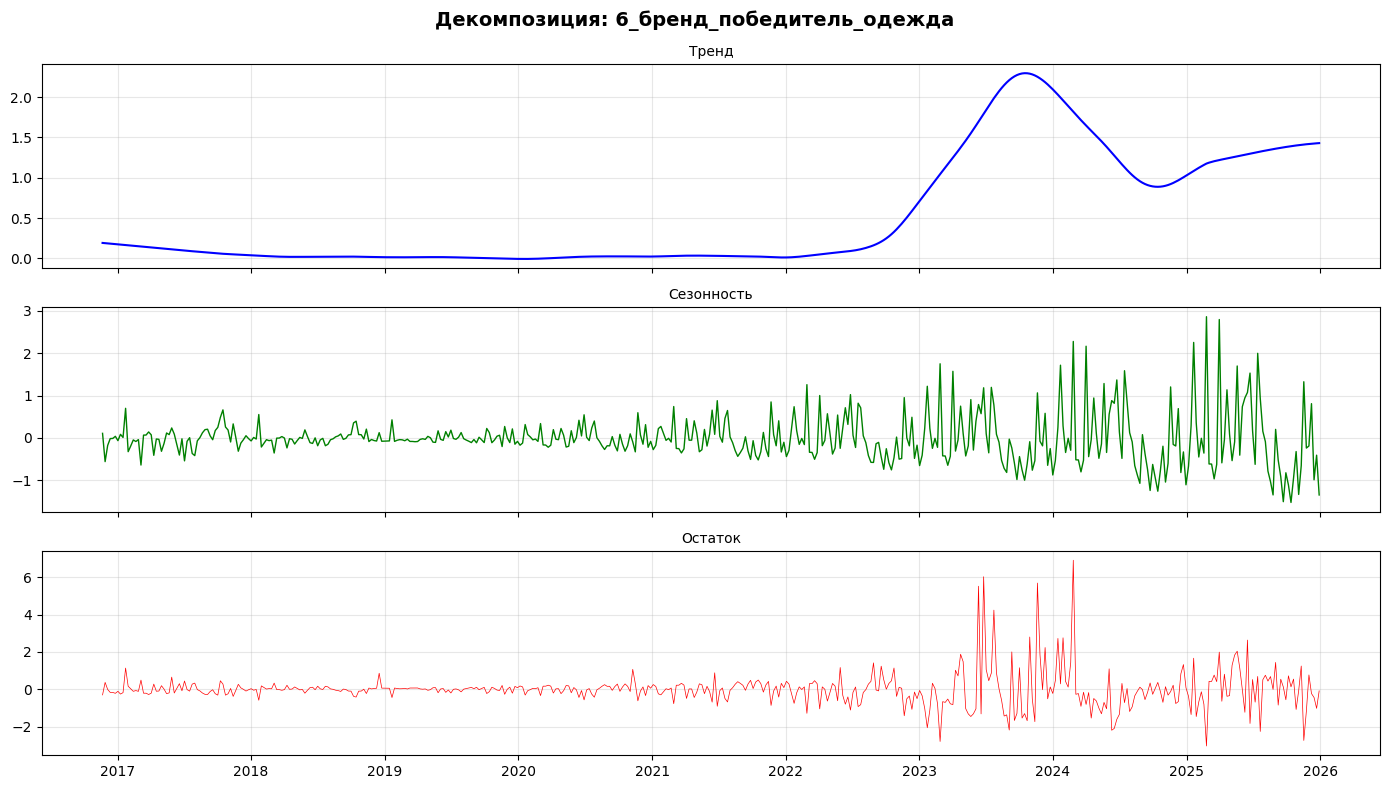

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Для разреженных данных лучше использовать STL
from statsmodels.tsa.seasonal import STL

for topic in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Декомпозиция: {topic}', fontsize=14, fontweight='bold')

    series = df[topic]

    # Пробуем STL с периодом 52 (годовая сезонность)
    stl = STL(series, period=52, seasonal=13)
    result = stl.fit()

    axes[0].plot(result.trend, color='blue', linewidth=1.5)
    axes[0].set_title('Тренд', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(result.seasonal, color='green', linewidth=1)
    axes[1].set_title('Сезонность', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(result.resid, color='red', linewidth=0.5)
    axes[2].set_title('Остаток', fontsize=10)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Сглаживание тренда

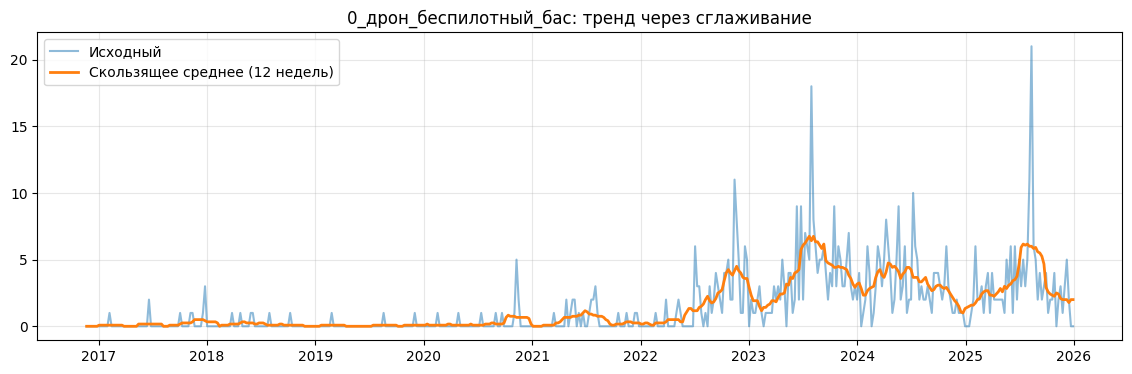

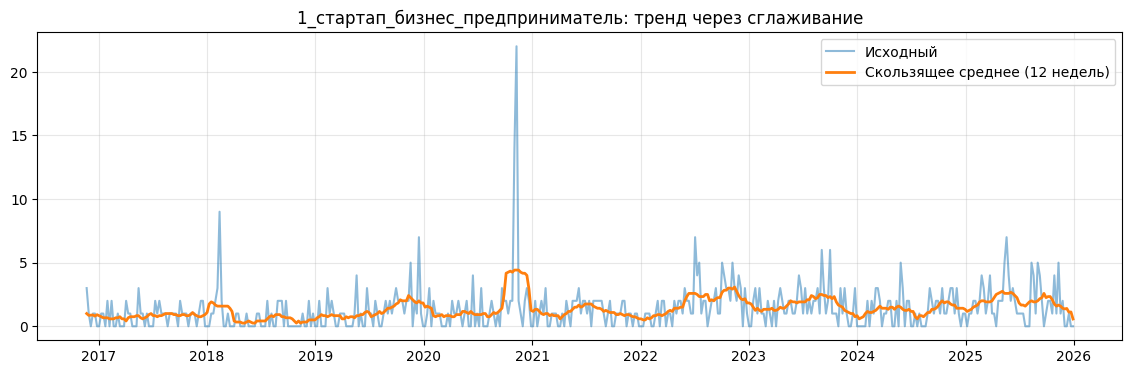

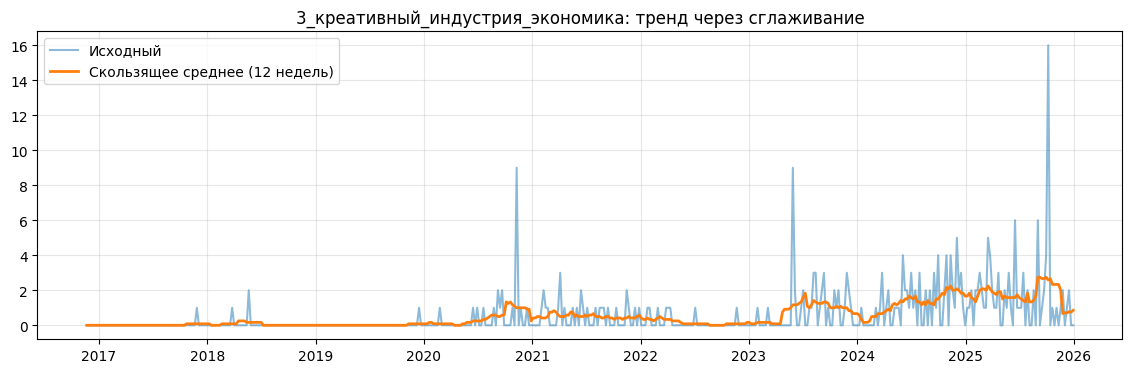

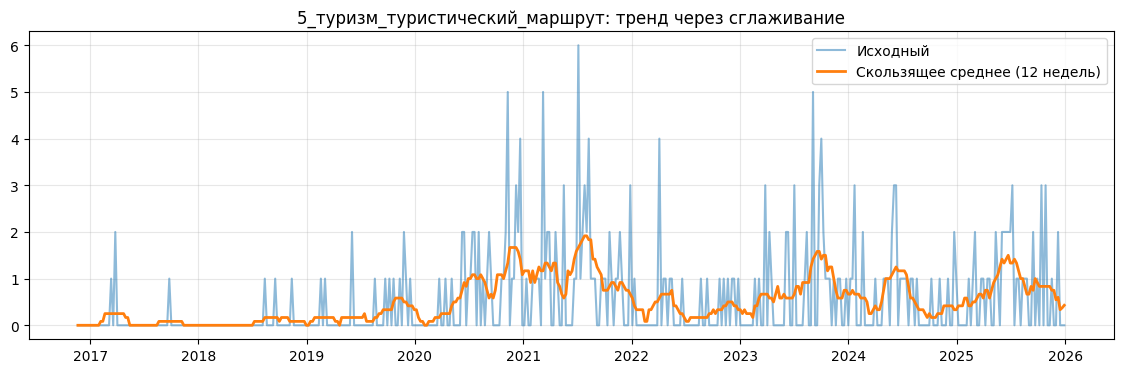

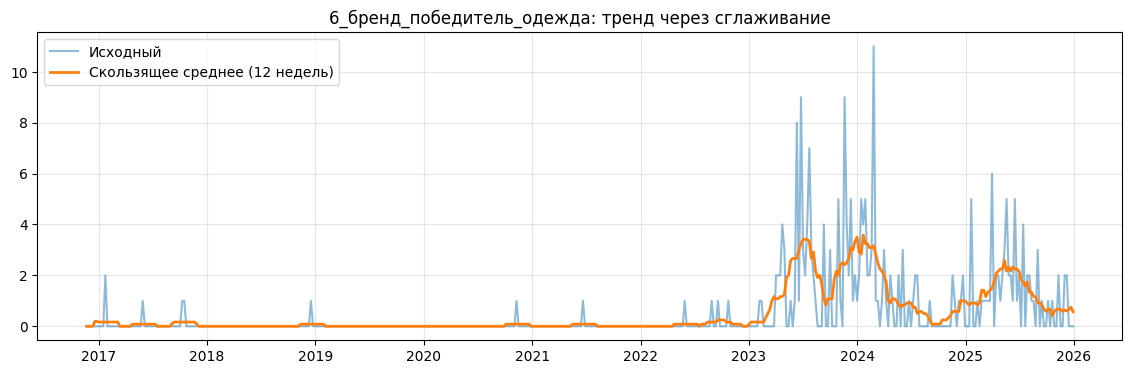

In [ ]:
# Простое скользящее среднее для дополнительного анализа тренда
df_smoothed = df.rolling(window=12, center=True, min_periods=1).mean()

for topic in df.columns:
    plt.figure(figsize=(14, 4))
    plt.plot(df[topic], label='Исходный', alpha=0.5)
    plt.plot(df_smoothed[topic], label='Скользящее среднее (12 недель)', linewidth=2)
    plt.title(f'{topic}: тренд через сглаживание')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

8. Прогнозирование временных рядов

Настройка окружения

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


Загрузка данных и разделение

In [ ]:
input_path = os.path.join(DATA_DIR, "topic_trends_top5.csv")
df = pd.read_csv(input_path, index_col=0, parse_dates=True).sort_index()

HORIZON = 12
TEST_WEEKS = 12
LOOK_BACK = 52

train = df.iloc[:-TEST_WEEKS]
test = df.iloc[-TEST_WEEKS:]

print(f"Train: {len(train)} | Test: {len(test)} | Horizon: {HORIZON}")

Train: 464 | Test: 12 | Horizon: 12


Классификация типов временного ряда

In [ ]:
from scipy.stats import linregress

def classify_topic(series, min_active=10, decay_threshold=0.1, sparse_threshold=0.7):
    """
    Классифицирует тип временного ряда темы

    Параметры:
    - series: временной ряд (pd.Series)
    - min_active: минимальное кол-во упоминаний за последний год для "живой" темы
    - decay_threshold: порог угасания (доля от пика)
    - sparse_threshold: порог разреженности (доля нулей)

    Возвращает: 'угасающий', 'разреженный', 'растущий', 'стабильный'
    """
    recent_year = series.tail(52)
    all_time_peak = series.max()
    recent_peak = series.rolling(52, min_periods=1).max().quantile(0.9)

    # Угасающая тема
    if recent_year.sum() < min_active and recent_year.mean() < decay_threshold * all_time_peak:
        return 'угасающий'

    # Очень разреженная (много нулей)
    zero_ratio = (series == 0).mean()
    if zero_ratio > sparse_threshold:
        return 'разреженный'

    # Проверка наличия тренда через линейную регрессию на последних 2 годах
    if len(series) >= 104:
        recent_2y = series.tail(104)
        x = np.arange(len(recent_2y))
        slope, _, rvalue, _, _ = linregress(x, recent_2y.values)

        # Тренд значим и достаточно сильный
        if rvalue**2 > 0.15 and abs(slope) > 0.005:
            return 'растущий' if slope > 0 else 'угасающий'

    # Стабильная тема
    return 'стабильный'

# Применяем классификацию ко всем темам
topic_types = {}
print("Классификация тем:\n")
for col in df.columns:
    topic_type = classify_topic(df[col])
    topic_types[col] = topic_type
    zero_pct = (df[col] == 0).mean() * 100
    recent_sum = df[col].tail(52).sum()
    print(f"{col:40s} {topic_type:10s} (нулей: {zero_pct:5.1f}%, за год: {recent_sum})")

Классификация тем:

0_дрон_беспилотный_бас                   стабильный (нулей:  54.8%, за год: 167)
1_стартап_бизнес_предприниматель         стабильный (нулей:  31.5%, за год: 99)
3_креативный_индустрия_экономика         разреженный (нулей:  71.6%, за год: 91)
5_туризм_туристический_маршрут           стабильный (нулей:  66.8%, за год: 41)
6_бренд_победитель_одежда                разреженный (нулей:  79.0%, за год: 67)


Функции подсчета метрик

In [ ]:
def calc_metrics(actual, predicted):
    """
    Расчет метрик
    """
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    # MAE только на ненулевых наблюдениях
    mask_nonzero = actual > 0
    if mask_nonzero.sum() > 0:
        mae_nonzero = mean_absolute_error(actual[mask_nonzero], predicted[mask_nonzero])
    else:
        mae_nonzero = np.nan

    # Hit Rate: доля верно предсказанных "активных" недель
    # (порог = 1 упоминание)
    actual_binary = (actual >= 1).astype(int)
    pred_binary = (predicted >= 1).astype(int)
    hit_rate = (actual_binary == pred_binary).mean()

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAE_nonzero': mae_nonzero,
        'HitRate': hit_rate
    }

def evaluate_forecasts(forecasts_dict, model_name):
    """
    Оценка по метрикам
    """
    results = []
    for col in df.columns:
        actual = test[col].values[:HORIZON]
        pred = forecasts_dict[col][:HORIZON]
        metrics = calc_metrics(actual, pred)
        metrics['Тема'] = col
        metrics['Модель'] = model_name
        results.append(metrics)
    return pd.DataFrame(results)

Наивный прогноз

In [ ]:
def seasonal_naive_forecast(series, horizon, seasonal_period=52):
    """
    Простейший сезонный наивный прогноз.
    Берет последние seasonal_period значений и повторяет их.
    """
    if len(series) < seasonal_period:
        # Если данных меньше периода, берем что есть
        last_values = series.values
    else:
        last_values = series.values[-seasonal_period:]

    # Повторяем последний сезон для горизонта прогноза
    forecast = np.tile(last_values, (horizon // seasonal_period) + 1)[:horizon]

    # Для количественных данных не допускаем отрицательных значений
    return np.maximum(forecast, 0)

# Генерируем прогнозы
naive_forecasts = {}
for col in df.columns:
    naive_forecasts[col] = seasonal_naive_forecast(train[col], HORIZON, seasonal_period=52)

# Оцениваем метрики
naive_metrics = evaluate_forecasts(naive_forecasts, "SeasonalNaive")
print("\nМетрики Seasonal Naive:")
print(naive_metrics[['Тема', 'RMSE', 'MAE']].to_string(index=False))


Метрики Seasonal Naive:
                            Тема     RMSE      MAE
          0_дрон_беспилотный_бас 1.755942 1.250000
1_стартап_бизнес_предприниматель 1.658312 1.416667
3_креативный_индустрия_экономика 2.309401 1.666667
  5_туризм_туристический_маршрут 1.581139 1.166667
       6_бренд_победитель_одежда 1.290994 1.000000


SARIMA

In [ ]:
try:
    import pmdarima as pm
    USE_AUTO = False # Можно заменять на True при необходимости автоподбора
except ImportError:
    USE_AUTO = False
    print("pmdarima not found. Using fixed parameters.")

sarima_forecasts = {}

for col in df.columns:
    series = train[col].dropna()

    if USE_AUTO:
        try:
            auto = pm.auto_arima(series, seasonal=True, m=52,
                                 max_p=3, max_q=3, max_P=2, max_Q=2,
                                 trace=False, suppress_warnings=True, stepwise=True)
            order, seasonal_order = auto.order, auto.seasonal_order
        except:
            order, seasonal_order = (1, 1, 1), (0, 0, 0, 52)
    else:
        order, seasonal_order = (1, 1, 1), (0, 0, 0, 52)

    model = SARIMAX(series, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False, maxiter=200)
    sarima_forecasts[col] = np.clip(res.forecast(steps=HORIZON).values, 0, None)
    print(f"SARIMA {col}: order={order}, seasonal={seasonal_order}")

SARIMA 0_дрон_беспилотный_бас: order=(1, 1, 1), seasonal=(0, 0, 0, 52)
SARIMA 1_стартап_бизнес_предприниматель: order=(1, 1, 1), seasonal=(0, 0, 0, 52)
SARIMA 3_креативный_индустрия_экономика: order=(1, 1, 1), seasonal=(0, 0, 0, 52)
SARIMA 5_туризм_туристический_маршрут: order=(1, 1, 1), seasonal=(0, 0, 0, 52)
SARIMA 6_бренд_победитель_одежда: order=(1, 1, 1), seasonal=(0, 0, 0, 52)


CatBoost

In [ ]:
catboost_forecasts = {}

for i, col in enumerate(df.columns):
    # Подготовка обучающих данных
    X, y = [], []
    for t in range(len(train) - LOOK_BACK - HORIZON + 1):
        X.append(train.iloc[t:t+LOOK_BACK].values.flatten())
        y.append(train.iloc[t+LOOK_BACK+HORIZON-1, i])

    X, y = np.array(X), np.array(y)

    # Обучение модели
    cb = CatBoostRegressor(
        iterations=300,          # Достаточно для сходимости на малой выборке
        learning_rate=0.05,      # Умеренный шаг для стабильности
        depth=5,                 # Ограничение сложности для защиты от переобучения на шуме
        l2_leaf_reg=3.0,         # L2-регуляризация (дополнительный контроль переобучения)
        loss_function='RMSE',    # Чувствительность к пикам активности
        random_seed=SEED,
        verbose=False
    )
    cb.fit(X, y)

    # Рекурсивное прогнозирование
    forecast = []
    history = train.iloc[-LOOK_BACK:].copy()

    for step in range(HORIZON):
        # Формируем признаки из текущего окна
        features = history.values.flatten().reshape(1, -1)
        pred = cb.predict(features)[0]
        pred = max(0, pred)  # Защита от отрицательных значений для количественных данных
        forecast.append(pred)

        # Обновляем окно: сдвигаем на 1 шаг, добавляем прогноз только для предсказываемой темы
        new_row = history.iloc[-1].copy()
        new_row[col] = pred
        history = pd.concat([history.iloc[1:], new_row.to_frame().T], ignore_index=True)

    catboost_forecasts[col] = np.array(forecast)
    print(f"CatBoost {col}: trained")

CatBoost 0_дрон_беспилотный_бас: trained
CatBoost 1_стартап_бизнес_предприниматель: trained
CatBoost 3_креативный_индустрия_экономика: trained
CatBoost 5_туризм_туристический_маршрут: trained
CatBoost 6_бренд_победитель_одежда: trained


LSTM: Данные и архитектура

In [ ]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train.values)

def create_windows(data, look_back, horizon):
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back:i + look_back + horizon])
    return np.array(X), np.array(y)

X_all, y_all = create_windows(scaled_train, LOOK_BACK, HORIZON)
val_idx = int(0.9 * len(X_all))
X_train, y_train = X_all[:val_idx], y_all[:val_idx]
X_val, y_val = X_all[val_idx:], y_all[val_idx:]

class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TSDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TSDataset(X_val, y_val), batch_size=32)

class LSTMForecaster(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, horizon, output_dim, dropout=0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden2, horizon * output_dim)
        self.horizon, self.output_dim = horizon, output_dim
    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop1(out)
        out, _ = self.lstm2(out)
        out = self.drop2(out[:, -1, :])
        out = self.fc(out)
        return out.view(-1, self.horizon, self.output_dim)

n_features = len(df.columns)
model_lstm = LSTMForecaster(n_features, 64, 32, HORIZON, n_features, dropout=0.3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

LSTM: Обучение

Epoch 1: train=0.02535, val=0.03377
Epoch 11: train=0.01227, val=0.01770
Epoch 21: train=0.01137, val=0.01637
Epoch 31: train=0.01095, val=0.01613
Epoch 41: train=0.01065, val=0.01606
Epoch 51: train=0.01062, val=0.01603
Early stop at epoch 58
Best model loaded (val_loss=0.01591)


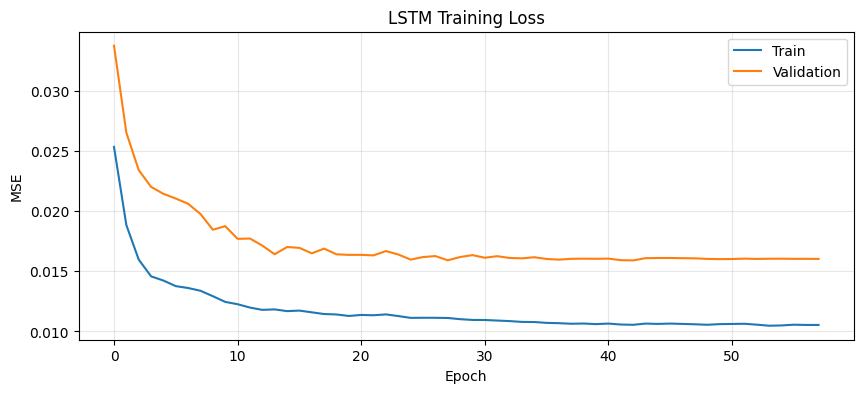

In [ ]:
best_loss, patience, wait = float('inf'), 15, 0
best_state, train_losses, val_losses = None, [], []

for epoch in range(1, 101):
    model_lstm.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_lstm(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(X_train)
    train_losses.append(train_loss)

    model_lstm.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            val_loss += criterion(model_lstm(xb.to(device)), yb.to(device)).item() * xb.size(0)
    val_loss /= len(X_val)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss, wait = val_loss, 0
        best_state = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stop at epoch {epoch}")
            break
    if epoch % 10 == 1 or epoch == 100:
        print(f"Epoch {epoch}: train={train_loss:.5f}, val={val_loss:.5f}")

if best_state:
    model_lstm.load_state_dict(best_state)
    print(f"Best model loaded (val_loss={best_loss:.5f})")

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train', linewidth=1.5)
plt.plot(val_losses, label='Validation', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('LSTM Training Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

LSTM: Прогноз

In [ ]:
model_lstm.eval()
last_seq = torch.tensor(scaled_train[-LOOK_BACK:].reshape(1, LOOK_BACK, -1), dtype=torch.float32).to(device)

with torch.no_grad():
    pred_scaled = model_lstm(last_seq).cpu().numpy().reshape(HORIZON, -1)

lstm_forecast = np.clip(scaler.inverse_transform(pred_scaled), 0, None)
lstm_forecasts = {col: lstm_forecast[:, i] for i, col in enumerate(df.columns)}

Сравнение моделей

In [ ]:
# Собираем все прогнозы в один словарь
all_forecasts = {
    'SeasonalNaive': naive_forecasts,
    'SARIMA': sarima_forecasts,
    'CatBoost': catboost_forecasts,
    'LSTM': lstm_forecasts
}

# Оцениваем все модели
all_metrics = []
for model_name, forecasts in all_forecasts.items():
    metrics_df = evaluate_forecasts(forecasts, model_name)
    all_metrics.append(metrics_df)

# Объединяем в одну таблицу
comparison_full = pd.concat(all_metrics, ignore_index=True)

# Сводная таблица RMSE по моделям и темам
pivot_rmse = comparison_full.pivot_table(
    index='Тема',
    columns='Модель',
    values='RMSE'
).round(3)

# Добавляем колонку "Лучшая модель"
pivot_rmse['Лучшая'] = pivot_rmse.idxmin(axis=1)

print("\nСРАВНЕНИЕ МОДЕЛЕЙ (RMSE):")
print(pivot_rmse.to_string())

# Средние метрики по всем темам
print("\nСРЕДНИЕ МЕТРИКИ ПО ВСЕМ ТЕМАМ:")
avg_metrics = comparison_full.groupby('Модель')[['RMSE', 'MAE', 'MAE_nonzero', 'HitRate']].mean()
print(avg_metrics.round(3).to_string())


СРАВНЕНИЕ МОДЕЛЕЙ (RMSE):
Модель                            CatBoost   LSTM  SARIMA  SeasonalNaive         Лучшая
Тема                                                                                   
0_дрон_беспилотный_бас               2.254  2.253   2.598          1.756  SeasonalNaive
1_стартап_бизнес_предприниматель     2.116  1.547   1.588          1.658           LSTM
3_креативный_индустрия_экономика     1.237  0.793   2.180          2.309           LSTM
5_туризм_туристический_маршрут       1.963  1.172   1.170          1.581         SARIMA
6_бренд_победитель_одежда            2.003  1.249   0.904          1.291         SARIMA

СРЕДНИЕ МЕТРИКИ ПО ВСЕМ ТЕМАМ:
                RMSE    MAE  MAE_nonzero  HitRate
Модель                                           
CatBoost       1.914  1.580        0.866    0.517
LSTM           1.403  1.218        0.988    0.600
SARIMA         1.688  1.498        1.277    0.650
SeasonalNaive  1.719  1.300        1.469    0.550


Визуализация

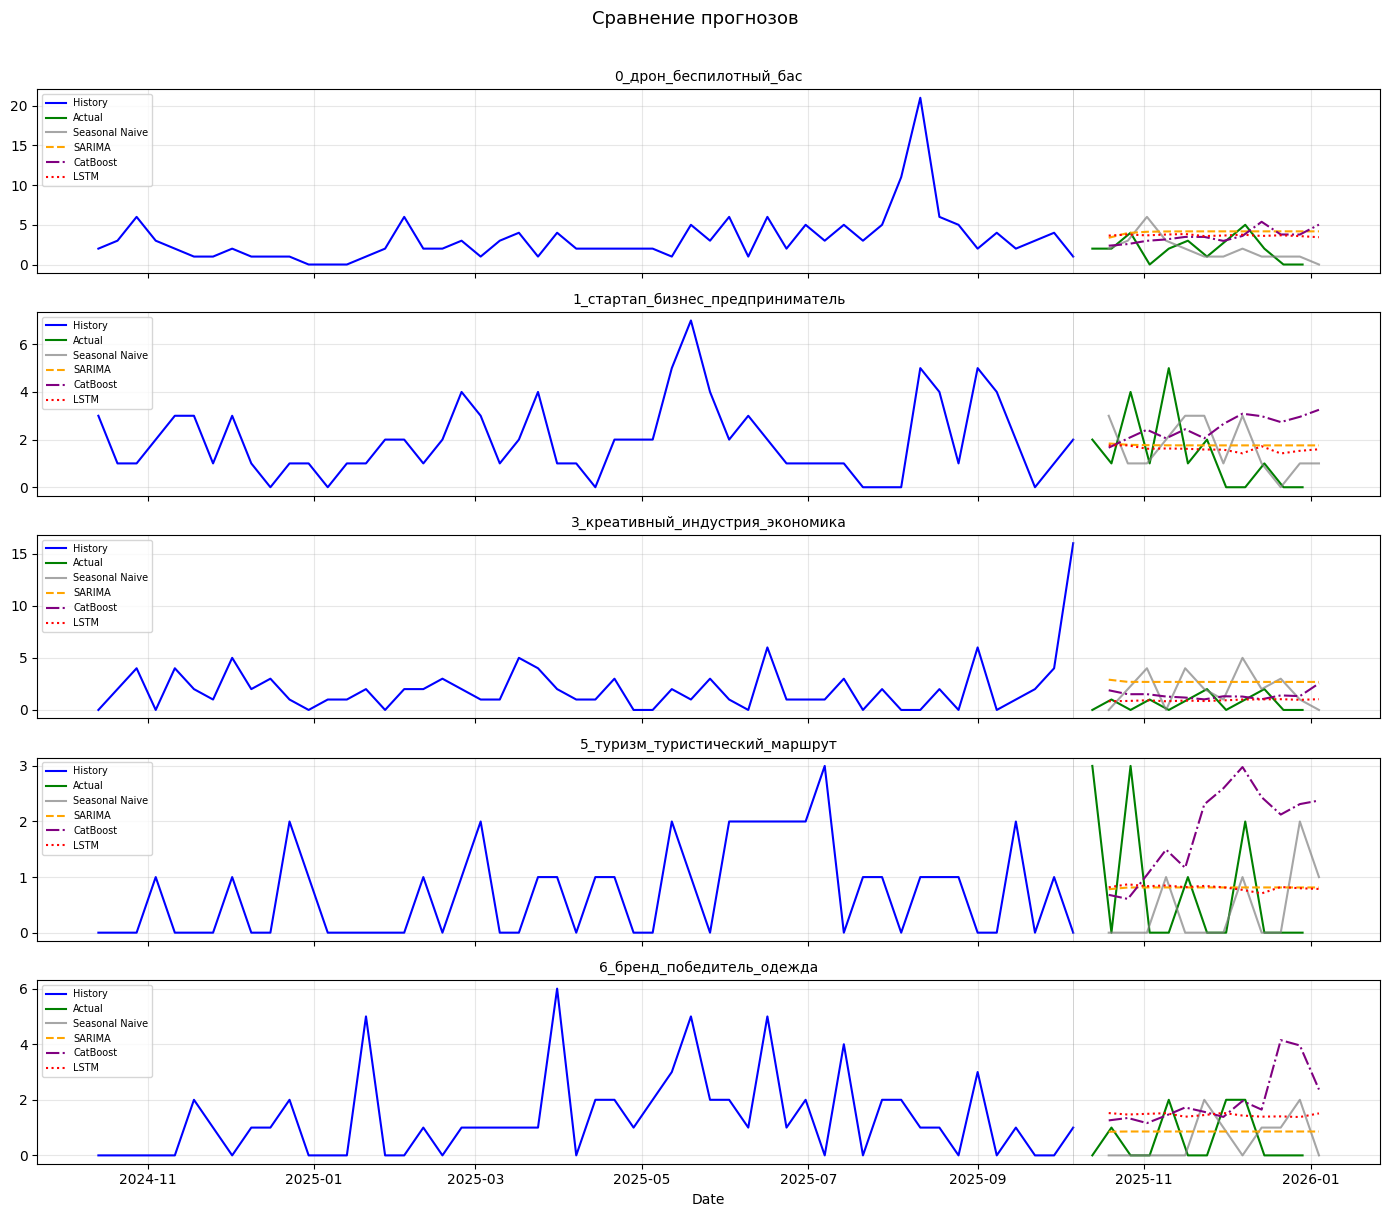

In [ ]:
forecast_dates = pd.date_range(start=train.index[-1] + pd.Timedelta(weeks=1), periods=HORIZON, freq='W')
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(df.columns):
    ax = axes[i]
    ax.plot(train.index[-52:], train[col].values[-52:], 'b-', lw=1.5, label='History')
    ax.plot(test.index[:HORIZON], test[col].values[:HORIZON], 'g-', lw=1.5, label='Actual')
    ax.plot(forecast_dates, naive_forecasts[col], 'gray', ls='-', lw=1.5, label='Seasonal Naive', alpha=0.7)
    ax.plot(forecast_dates, sarima_forecasts[col], 'orange', ls='--', lw=1.5, label='SARIMA')
    ax.plot(forecast_dates, catboost_forecasts[col], 'purple', ls='-.', lw=1.5, label='CatBoost')
    ax.plot(forecast_dates, lstm_forecasts[col], 'red', ls=':', lw=1.5, label='LSTM')
    ax.axvline(train.index[-1], color='gray', lw=0.5, alpha=0.5)
    ax.set_title(col, fontsize=10)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Сравнение прогнозов', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

9. Сохранение моделей для дашборда

In [ ]:
import joblib
import os
import json
import torch
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

TOPICS = df.columns.tolist()
print(f"Сохранение моделей для тем: {TOPICS}")

print("Сохранение SARIMA моделей...")
FIXED_ORDER = (1, 1, 1)
FIXED_SEASONAL = (0, 0, 0, 52)

for col in TOPICS:
    series = train[col].dropna()
    model = SARIMAX(series, order=FIXED_ORDER, seasonal_order=FIXED_SEASONAL,
                    enforce_stationarity=False, enforce_invertibility=False)
    results = model.fit(disp=False, maxiter=200)
    joblib.dump(results, os.path.join(MODEL_DIR, f"sarima_{col}.pkl"))
print("SARIMA сохранены.")

print("Сохранение CatBoost моделей...")
for i, col in enumerate(TOPICS):
    X_cb, y_cb = [], []
    # Используем только обучающую выборку, как в основном пайплайне
    for t in range(len(train) - LOOK_BACK - HORIZON + 1):
        X_cb.append(train.iloc[t:t+LOOK_BACK].values.flatten())
        y_cb.append(train.iloc[t+LOOK_BACK+HORIZON-1, i])

    X_cb, y_cb = np.array(X_cb), np.array(y_cb)

    cb_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                 l2_leaf_reg=3.0, loss_function='RMSE',
                                 random_seed=SEED, verbose=False)
    cb_model.fit(X_cb, y_cb)
    cb_model.save_model(os.path.join(MODEL_DIR, f"catboost_{col}.cbm"))
print("CatBoost модели сохранены.")

print("Сохранение LSTM и Scaler...")
torch.save({
    'model_state_dict': best_state,
    'input_dim': len(TOPICS),
    'hidden_dim1': 64,
    'hidden_dim2': 32,
    'horizon': HORIZON,
    'output_dim': len(TOPICS),
    'dropout': 0.3
}, os.path.join(MODEL_DIR, "lstm_model.pt"))

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
print("LSTM и Scaler сохранены.")

print("Сохранение метаданных тем...")
topic_keywords = {
    '0_дрон_беспилотный_бас': ['дрон', 'беспилотный', 'бас', 'авиация', 'система'],
    '1_стартап_бизнес_предприниматель': ['стартап', 'бизнес', 'предприниматель', 'команда', 'акселератор'],
    '3_креативный_индустрия_экономика': ['креативный', 'индустрия', 'экономика', 'творческий', 'партнёр'],
    '5_туризм_туристический_маршрут': ['туризм', 'туристический', 'маршрут', 'тропа', 'турист'],
    '6_бренд_победитель_одежда': ['бренд', 'победитель', 'одежда', 'номинация', 'продукция']
}

topic_meta = {}
for col in TOPICS:
    topic_meta[col] = {
        'keywords': topic_keywords.get(col, []),
        'total_messages': int(df[col].sum()),
        'description': f"Тематический тренд по ключевым словам: {', '.join(topic_keywords.get(col, []))}"
    }

with open(os.path.join(MODEL_DIR, "topic_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(topic_meta, f, ensure_ascii=False, indent=2)
print("Метаданные сохранены.")

print("Сохранение метрик...")
actual_all = test.values[:HORIZON]

# Собираем матрицы прогнозов
sarima_all = np.array([sarima_forecasts[col] for col in TOPICS]).T
catboost_all = np.array([catboost_forecasts[col] for col in TOPICS]).T
lstm_all = np.array([lstm_forecasts[col] for col in TOPICS]).T

detailed_metrics = {}
for i, col in enumerate(TOPICS):
    detailed_metrics[col] = {
        'SARIMA_RMSE': round(np.sqrt(mean_squared_error(actual_all[:, i], sarima_all[:, i])), 3),
        'CatBoost_RMSE': round(np.sqrt(mean_squared_error(actual_all[:, i], catboost_all[:, i])), 3),
        'LSTM_RMSE': round(np.sqrt(mean_squared_error(actual_all[:, i], lstm_all[:, i])), 3)
    }

metrics_summary = {
    'SARIMA_RMSE': round(np.sqrt(mean_squared_error(actual_all, sarima_all)), 3),
    'CatBoost_RMSE': round(np.sqrt(mean_squared_error(actual_all, catboost_all)), 3),
    'LSTM_RMSE': round(np.sqrt(mean_squared_error(actual_all, lstm_all)), 3),
    'test_period_start': str(test.index[0].date()),
    'test_period_end': str(test.index[-1].date()),
    'detailed': detailed_metrics
}

with open(os.path.join(MODEL_DIR, "metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Метрики сохранены.")
print(f"Все данные сохранены в: {os.path.abspath(MODEL_DIR)}")

Сохранение моделей для тем: ['0_дрон_беспилотный_бас', '1_стартап_бизнес_предприниматель', '3_креативный_индустрия_экономика', '5_туризм_туристический_маршрут', '6_бренд_победитель_одежда']
Сохранение SARIMA моделей...
SARIMA сохранены.
Сохранение CatBoost моделей...
CatBoost модели сохранены.
Сохранение LSTM и Scaler...
LSTM и Scaler сохранены.
Сохранение метаданных тем...
Метаданные сохранены.
Сохранение метрик...
Метрики сохранены.
Все данные сохранены в: /content/drive/MyDrive/Научная работа/models
